## MCP Cleint Architecture and Fundamentals

### Objectivds
- 3 layer architecture of MCP
- Unserstand the fundamentals of MCP client communications
    - lifecycle phases
    - capacity negotiation
- Describe the MCP server primitives, and the basics of STDIO transport
- Explain how MCP support a multi-sever client architecture
- Describe the difference between TypeScirpt and Python SDKs for MCP
- Test and validate MCP clients

### 3 layer archtecture
- Host: manages clients
- Client: connect with exactly one server
    - one client connect with exactly one server
- Sever
    - Prmitives: (resources, tools, prompts)

### Json-RPC 2.0
- 3 message types
    - Requests
        - expect a `result` or an `error`
    - Reponses
    - Notification
        - no id or no response
- 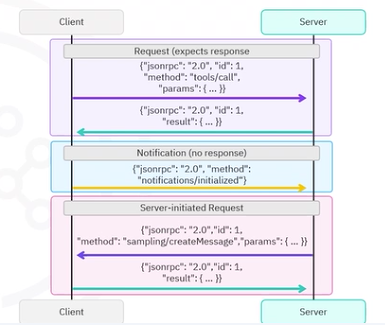
- bidirectional communication
- All messages are JSON objects over STDIO or Stramable HTTP

### MCP client connection: Three phases
- Phase 1: initialization
    - client sends initialize request with protocol version and client capabilites
    - sever responds with its capabilites  and protocol version
    - Client **MUST** send an initialized notification to complete the handshake
    - 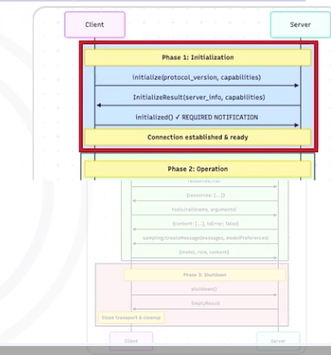

- Phase 2: Operation
    - Client discover capabilites using `list_tools`, `list_resources` and `list_prompts`
    - Cleit invokes tools, read resources, and get prompts
    - Server can request sampling

- Phase 3: shutdown
    - Client sends shutdown request
    - Server responds
    - Connection closes with cleanup process

### Capability negotiation
- 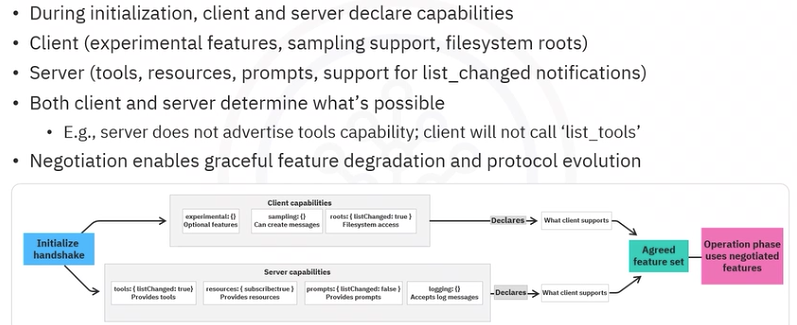

### MCP primitives: Tools, resources, and prompts
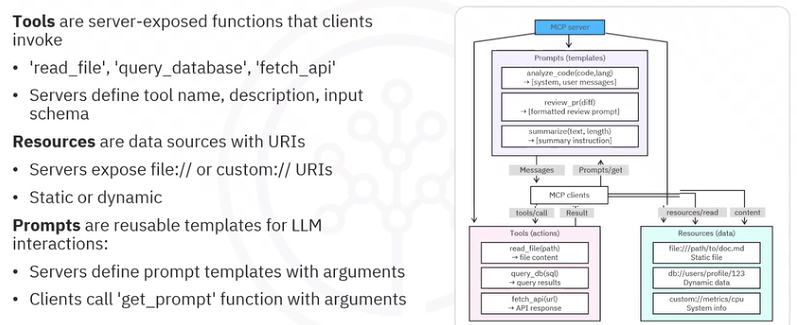

### STDIO trasport
- simplest trasport mechanism
- client spawns a server process






## Streamable HTTP, Roots, and Sampling

### Learning objectives
- diff between STDIO and Streamable HTTP trasport
- message flow in HTTP trasport
- implement HTTP trasport for an MCP client
- sampling feature in MCP
- root feature in MCP environment
- Describe multi-trasport session management in MCP

### STDIO vs Streamable HTTP
- MCP support 2 trasnport
- STDIO Trasport
    - 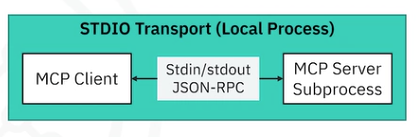
    - perfect for local tools
- HTTP trasport
    - 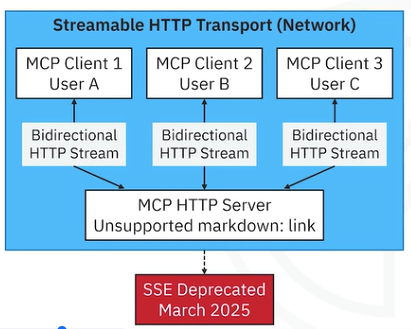
    - can suppot multiple clients at the same time
- comparison of two transports
- 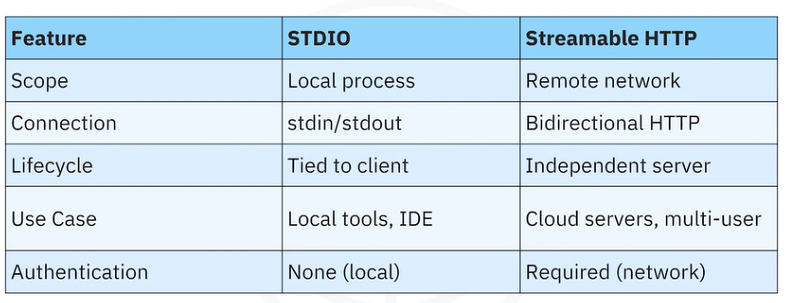

### HTTP message flow in MCP
- 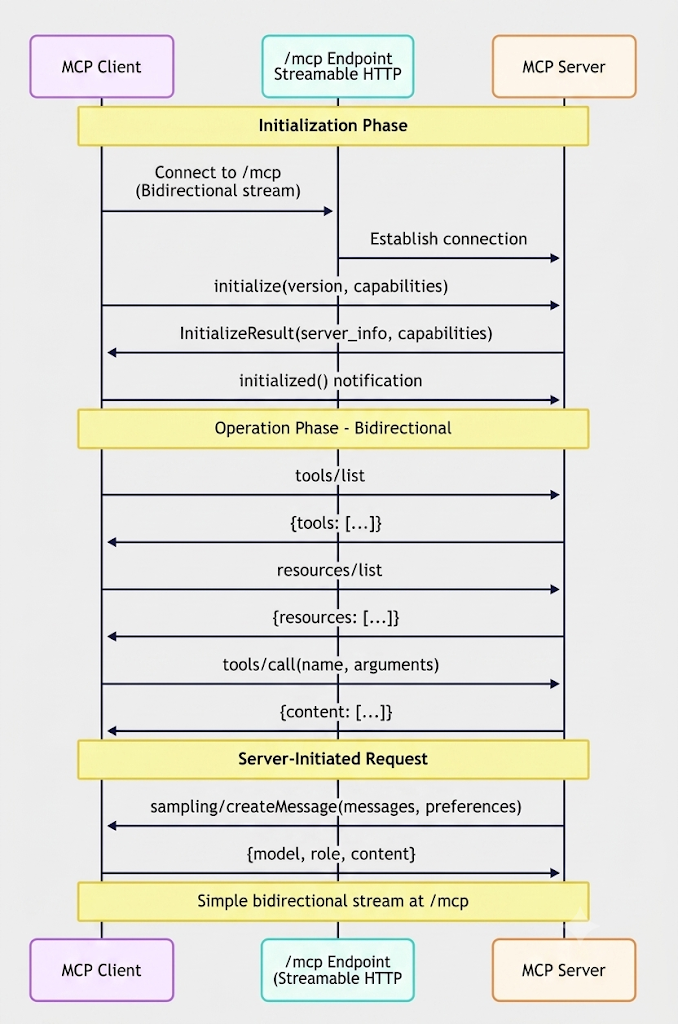
- client connects to the server's mcp endpoint
- client and server can send messages trhough this connection
- Client sends JSON-RCP requests, and the server responds with results
- server can also initiate requests- such as sampling for LLM capabilites and the clietn responds
- Notifications flows both the directions without responses

### Implementing Streamable HTTP in MCP client
- 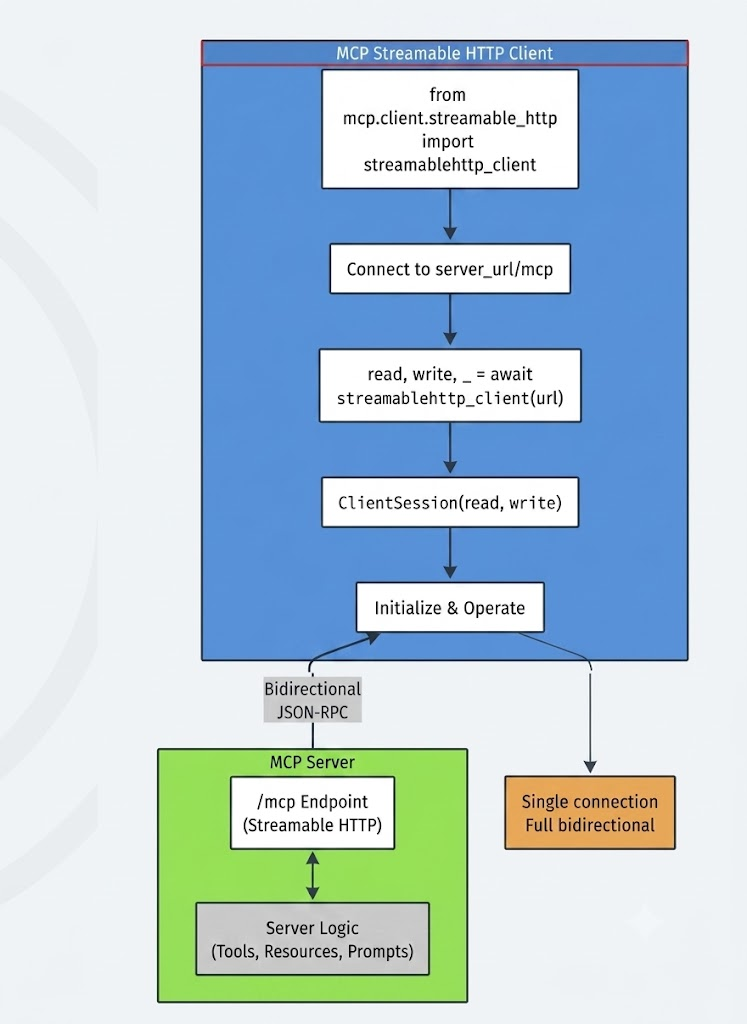

- import streamablehttp_client from SDK
- connect to server '/mcp' endpoint
- Client retuns three values
    - read stream
    - write stream
    - session info
- Use streams to create ClientSession
- call 'initialize' to negotiate capabilites and send initalized notification
- Client automatically handles message framing, error recovery, and connection management

#### Client implementation pattern
```python
from mcp.client.streamable_http import streamablehttp_client
from mcp import ClientSession

# connect to server
server_url = "http://127.0.0.1:8000/mcp"
read, write, _ = await streamablehttp_client(server_url)

# Create session
session = ClientSession(read, write)
await session.initialize()
```

### Sampling server
- Sampling lets servers request LLM capabilites from the client during tool execution
    - server executes a tool and dtermines it needs LLM reasoning
    - Server sends sampling/createMessage request with messages array, system prompt, model peferences, and generation parameters
    - Client receives request and prompts user for approval (cost control, security)
    - After user approval, cient invokes the LLM
    - LLM response flows back through client to server, incorporated into tool results

- example sampling request schema
- 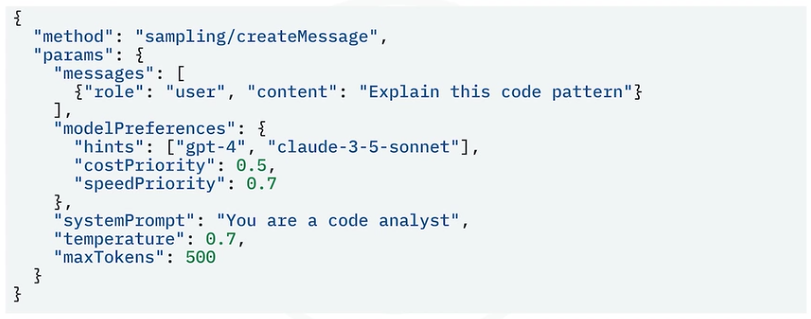


